<font color='green' size=6>**Решающие деревья**



Решающее дерево состоит из вершин, в каждой из которой записан **предикат/правило**: то есть логическое выражение вида $[x_{ij} < t]$.

Процесс обучения дерева:
 - обучающая выборка разбивается на подгруппы согласно тестируемому правилу/предикату
 - на каждом шаге разбиения выборки выбирается наилучший предикат/правило исходя из **критерия информативности**


Запишем задачу формально: мы находимся в узле с множеством объектов $R_m$ и наша цель разбить множество на 2 подмножества: $R_l$ и $R_r$.
Оценивать качество разбиения мы будем следующим образом:
$$H(R_m) - \frac{|R_l|}{|R_m|}H(R_l) - \frac{|R_r|}{|R_m|}H(R_r) \to \max.$$

Нам необходимо найти такую функцию $H(x)$, которая будет оценивать различия и сходства объектов.


Официальная документация - https://scikit-learn.org/stable/modules/tree.html#tree-mathematical-formulation


Функция $H(x)$ зависит от задачи, которую мы решаем

**Регрессия**
1. MSE — дисперсия целевой переменной
$$H(R) = \frac{1}{|R|} \sum_{(x_i, y_i) \in R}{}(y_i - \hat{y})^2$$

2. MAE — отклонение от медианы
$$H(R) = \frac{1}{|R|} \sum_{(x_i, y_i) \in R}{}\frac{|y_i - MEDIAN(Y)|}{|R|}$$

**Классификация**

Обозначим $p_k$ долю объектов класса $k$ во множестве объектов $R$.
1. Энтропия
$$H(R) = -\sum_{k=1}^{K} p_k log(p_k)$$

2. Критерий Джини
$$H(R) = 1 -  \sum_{k=1}^{K} p_k^2 = \sum_{k=1}p_k(1-p_k)$$



In [103]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_wine

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text, export_graphviz

import graphviz

from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

In [36]:

%matplotlib inline
plt.rcParams["figure.figsize"] = (7, 5)

In [37]:
# фиксируем для вопроизводимости
my_random_state = 12345

# <font color='green' size=5>Что выбрать? Линейные модели или решающие деревья



- Линейная модель --> данные хорошо линейно разделимы
- Решающие деревья --> данные плохо линейно разделимы

In [38]:
# сгенерим данные
np.random.seed(my_random_state)
n = 100
X = np.zeros(shape=(n, 2))
# X

In [39]:
X[:, 0] = np.linspace(-5, 5, n)
# X

In [40]:
X[:, 1] = X[:, 0] + 0.5 * np.random.normal(size=n)
# X

In [41]:
y = (X[:, 1] > X[:, 0]).astype(int)
y

array([0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1])

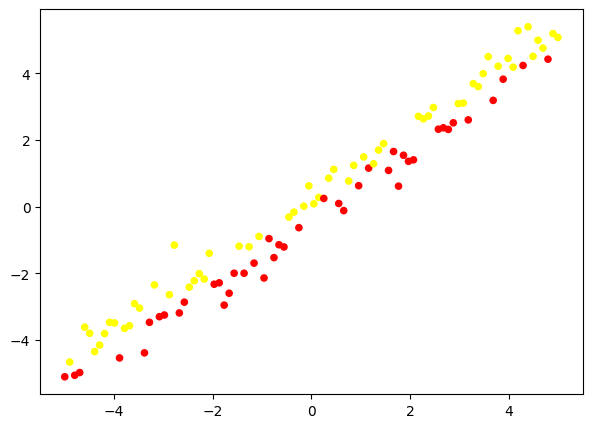

In [42]:
plt.scatter(X[:, 0], X[:, 1], s=20, c=y, cmap="autumn")
plt.show()

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=my_random_state)

lr = LogisticRegression(random_state=my_random_state)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Accuracy логистическая регрессии: {round(accuracy_score(y_pred_lr, y_test),2)}")

Accuracy логистическая регрессии: 0.9


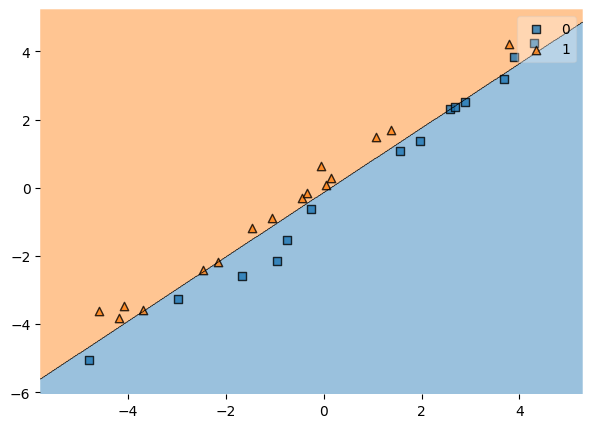

In [44]:
plot_decision_regions(X_test, y_test, lr);

In [45]:
dt = DecisionTreeClassifier(random_state=my_random_state)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Decision tree accuracy: {accuracy_score(y_pred_dt, y_test):.2f}")

Decision tree accuracy: 0.70


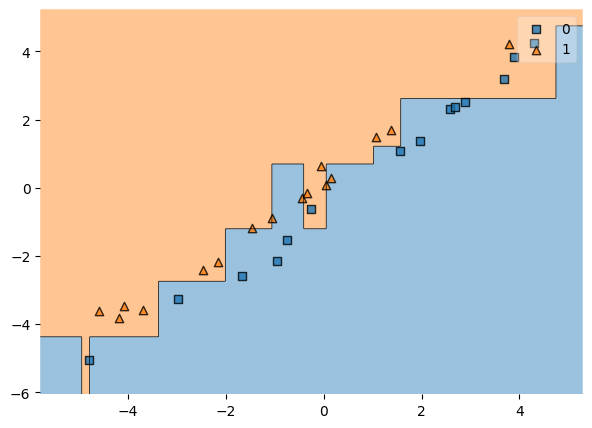

In [46]:
plot_decision_regions(X_test, y_test, dt);

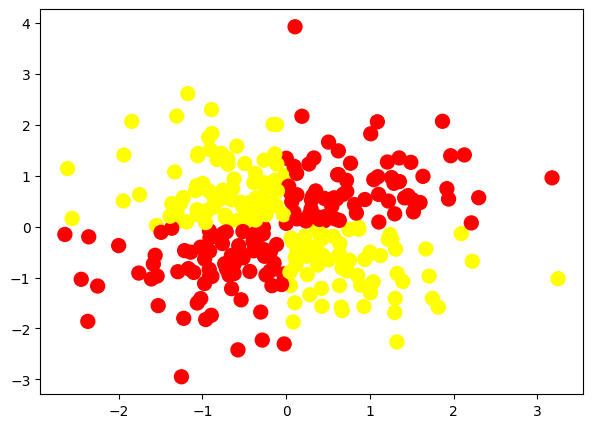

In [47]:
np.random.seed(my_random_state)
n = 300
X = np.random.randn(n, 2)
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y, cmap="autumn");

Accuracy для логистичская регрессии: 0.43


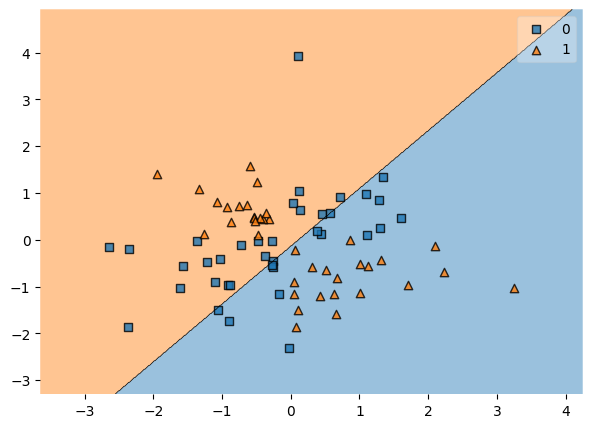

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=my_random_state
)

lr = LogisticRegression(random_state=my_random_state)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(f"Accuracy для логистичская регрессии: {round(accuracy_score(y_pred_lr, y_test),2)}")

plot_decision_regions(X_test, y_test, lr);

DecisionTree model accuracy: 0.96


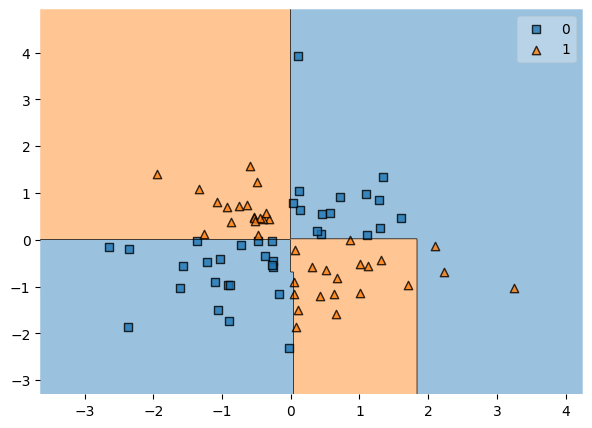

In [49]:
dt = DecisionTreeClassifier(random_state=my_random_state)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"DecisionTree model accuracy: {accuracy_score(y_pred_dt, y_test):.2f}")

plot_decision_regions(X_test, y_test, dt);

# <font color='green' size=5> Может ли дерево переобучиться?

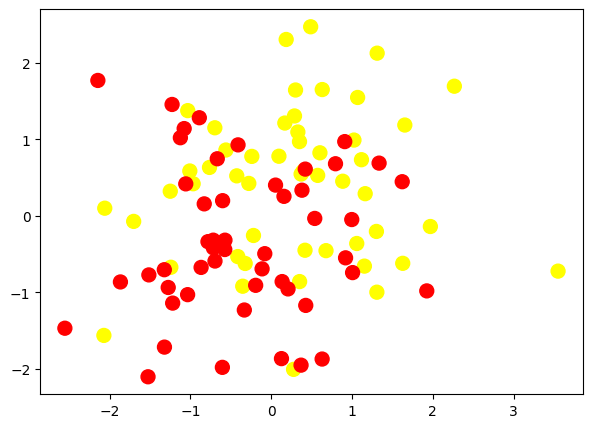

In [50]:
np.random.seed(my_random_state)
n = 100
X = np.random.normal(size=(n, 2))
X[:50, :] += 0.3
X[50:, :] -= 0.3
y = np.array([1] * 50 + [0] * 50)
plt.scatter(X[:, 0], X[:, 1], s=100, c=y, cmap="autumn");

In [51]:
# ?DecisionTreeClassifier

Протестируем следующие гиперапараметры:

- `max_depth`: максимальная глубина дерева
- `min_samples_leaf`: минимальное число объектов в вершине дерева, необходимое для того, чтобы она стала листовой

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state = 42)

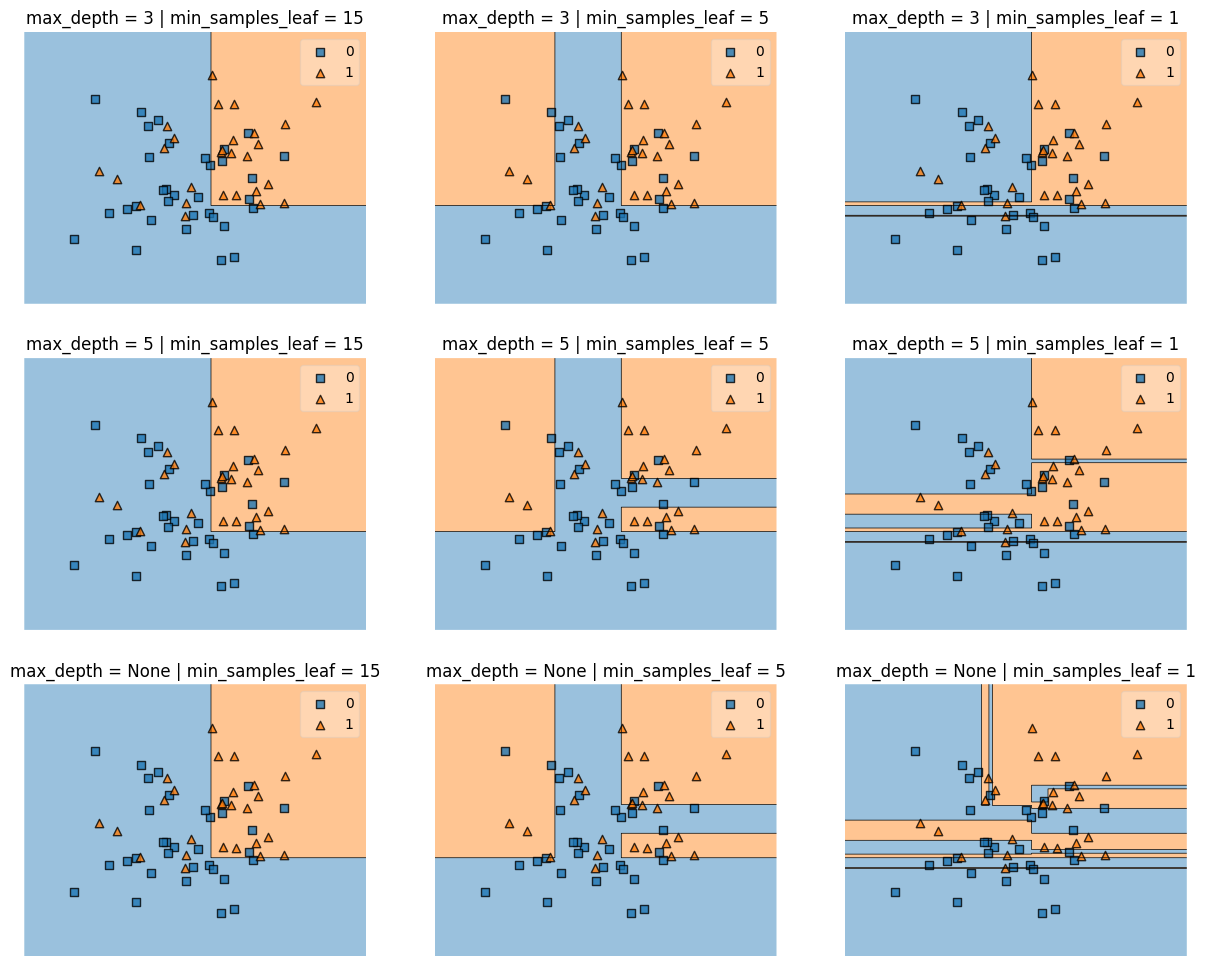

In [53]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i, max_depth in enumerate([3, 5, None]):
    for j, min_samples_leaf in enumerate([15, 5, 1]):
        dt = DecisionTreeClassifier(
            max_depth=max_depth, min_samples_leaf=min_samples_leaf, random_state=my_random_state
        )
        dt.fit(X_train, y_train)
        ax[i][j].set_title(
            "max_depth = {} | min_samples_leaf = {}".format(max_depth, min_samples_leaf)
        )
        ax[i][j].axis("off")
        plot_decision_regions(X_train, y_train, dt, ax=ax[i][j])

plt.show()

Accuracy для дерева решений: 1.0


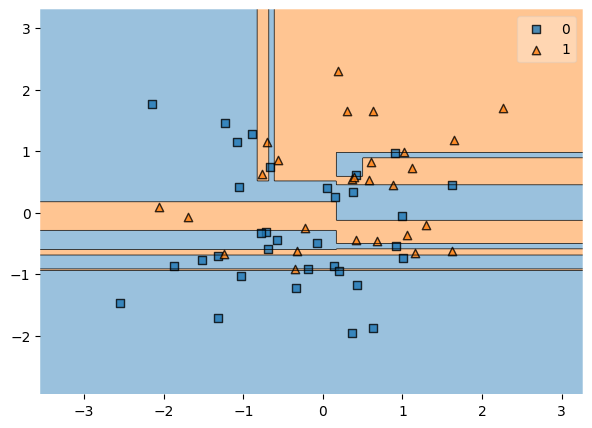

In [54]:
dt = DecisionTreeClassifier(max_depth=None, min_samples_leaf=1, random_state=my_random_state)
dt.fit(X_train, y_train)

print(f"Accuracy для дерева решений: {round(accuracy_score(y_train, dt.predict(X_train)),2)}")

plot_decision_regions(X_train, y_train, dt);

Accuracy для дерева решений: 0.53


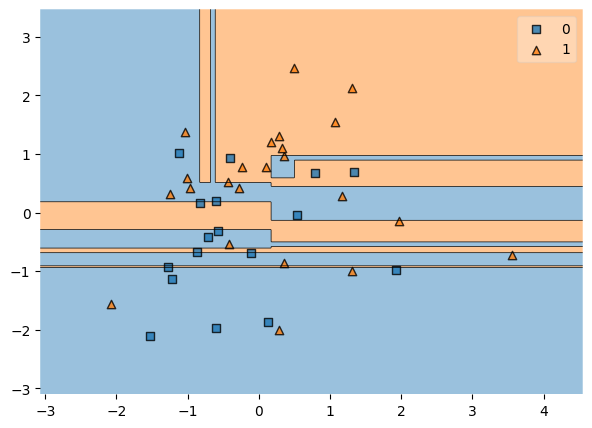

In [55]:
print(f"Accuracy для дерева решений: {round(accuracy_score(y_test, dt.predict(X_test)),2)}")
plot_decision_regions(X_test, y_test, dt);

> то есть деревья склонны к переобучению

Неустойчивость решающих деревьев

Посмотрим, как будет меняться структура дерева, если брать для обучения разные 90%-ые подвыборки исходной выборки.

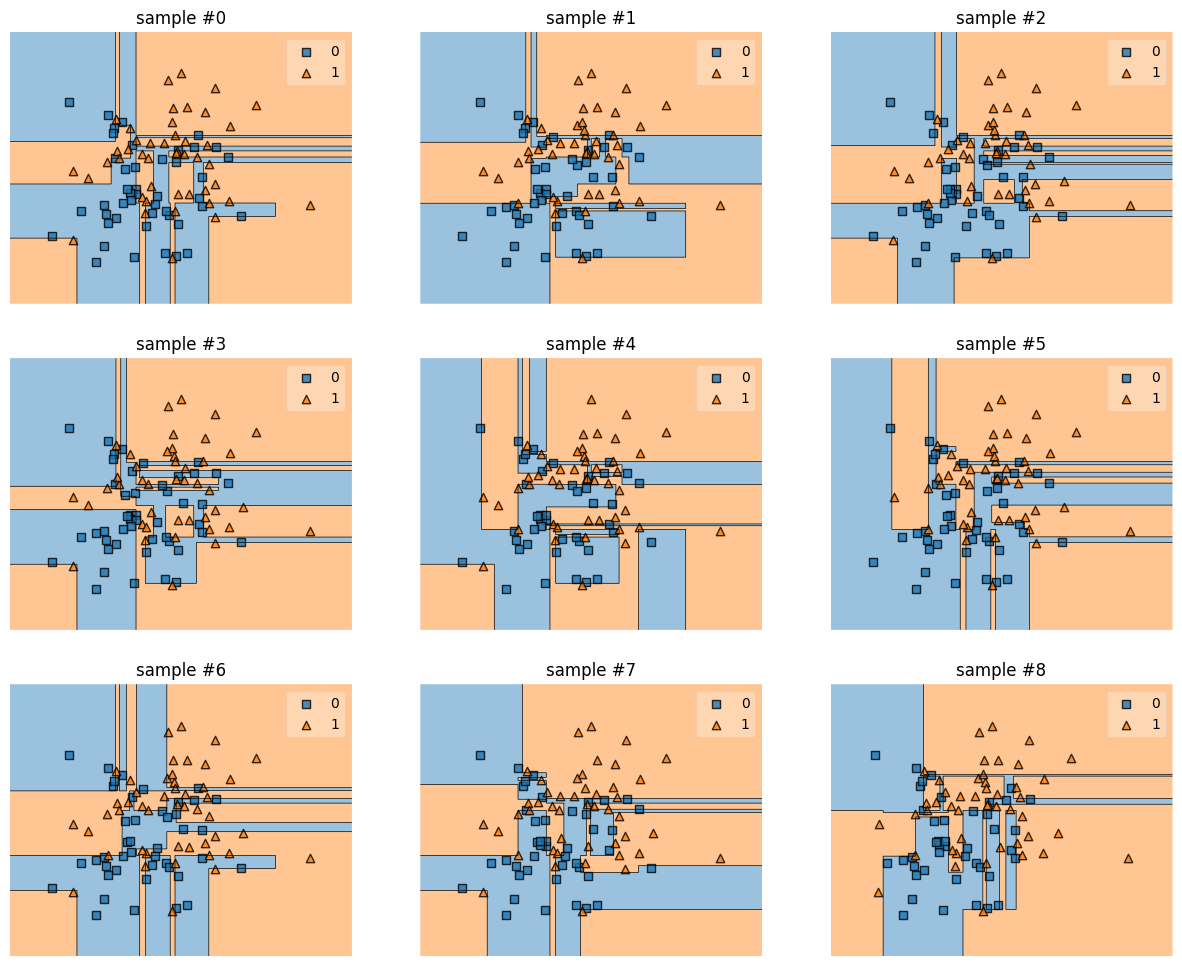

In [56]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))

for i in range(3):
    for j in range(3):
        seed_idx = 3 * i + j
        np.random.seed(seed_idx)
        dt = DecisionTreeClassifier(random_state=my_random_state)
        idx_part = np.random.choice(len(X), replace=False, size=int(0.9 * len(X)))
        X_part, y_part = X[idx_part, :], y[idx_part]
        dt.fit(X_part, y_part)
        ax[i][j].set_title("sample #{}".format(seed_idx))
        ax[i][j].axis("off")
        plot_decision_regions(X_part, y_part, dt, ax=ax[i][j])

plt.show()

<font size=5>вывод:
- деревья неустойчивые и склонны к переобучнию

# <font color='green' size=5> Решение практической задачи при помощи решающих деревьев

In [57]:
# Загрузка датасета Вин
wine = load_wine()
# X, y = wine.data, wine.target

X = pd.DataFrame(data=wine.data, columns=wine.feature_names)
y = wine.target
print(f"X shape: {X.shape}, Y shape: {y.shape}")
X.head()

X shape: (178, 13), Y shape: (178,)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


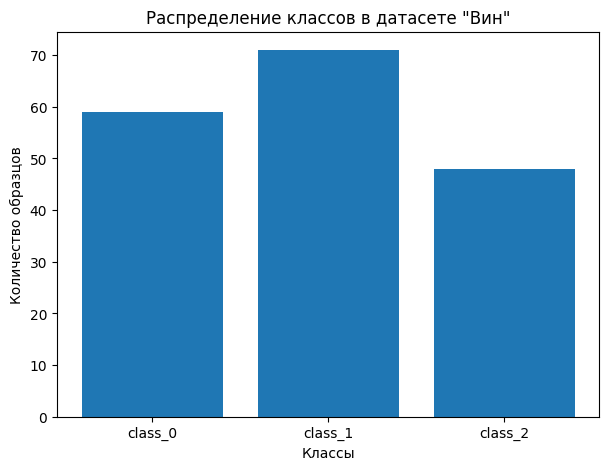

In [58]:
# Посчитаем количество образцов для каждого класса
unique_classes, counts = np.unique(y, return_counts=True)

# Отобразим бар-плот
plt.bar(unique_classes, counts, tick_label=wine.target_names)
plt.xlabel('Классы')
plt.ylabel('Количество образцов')
plt.title('Распределение классов в датасете "Вин"')
plt.show()

Описание признаков (характеристик):

- Alcohol (Алкоголь): содержание алкоголя в вине (% по объему)
- Malic Acid (Яблочная кислота): содержание яблочной кислоты в вине (г/л)
- Ash (Зольность): содержание минералов, представленное зольностью (% по массе)
- Alcalinity of Ash (Щелочность золы): общая щелочность золы (г/л)
- Magnesium (Магний): содержание магния в вине (мг/л)
Total Phenols (Общие фенолы): общее содержание фенолов в вине (г/л)
- Flavanoids (Флавоноиды): содержание флавоноидов в вине (г/л)
- Nonflavanoid Phenols (Нефлавоноидные фенолы): содержание нефлавоноидных фенолов в вине (г/л)
- Proanthocyanins (Проантоцианидины): содержание проантоцианидинов в вине (г/л)
- Color Intensity (Интенсивность цвета): интенсивность цвета виноградного сока (от 1 до 10)
- Hue (Оттенок): оттенок вина, измеренный в градусах от 0 до 360
- OD280/OD315 of diluted wines (OD280/OD315 разбавленных вин): соотношение оптической плотности разбавленных вин при длине волны 280/315 нм
- Proline (Пролин): содержание пролина в вине (мг/л)

**Целевая переменная (классы):**

- Class_0: сорт 1
- Class_1: сорт 2
- Class_2: сорт 3


In [96]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=my_random_state
)

dt_classifier = DecisionTreeClassifier(max_depth=5, min_samples_leaf = 20, random_state=my_random_state)
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=12345)

In [97]:
# Получение предсказанных меток классов на тестовой выборке
y_pred_test = dt_classifier.predict(X_test)
y_pred_train = dt_classifier.predict(X_train)
# Вычисление точности
accuracy_test = accuracy_score(y_test, y_pred_test)
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_train, accuracy_test

(0.8943661971830986, 0.8611111111111112)

In [98]:

text_representation = export_text(dt_classifier)
print(text_representation)

|--- feature_12 <= 755.00
|   |--- feature_11 <= 2.11
|   |   |--- class: 2
|   |--- feature_11 >  2.11
|   |   |--- feature_12 <= 506.00
|   |   |   |--- class: 1
|   |   |--- feature_12 >  506.00
|   |   |   |--- class: 1
|--- feature_12 >  755.00
|   |--- feature_0 <= 13.46
|   |   |--- class: 0
|   |--- feature_0 >  13.46
|   |   |--- class: 0



In [99]:
# Визуализация дерева решений с помощью Graphviz
dot_data = export_graphviz(dt_classifier, out_file=None,
                           feature_names=wine.feature_names,
                           class_names=wine.target_names,
                           filled=True, rounded=True, special_characters=True)

graph = graphviz.Source(dot_data)
graph.render("wine_tree")  # Сохраняем дерево в файл "wine_tree.pdf"
graph.view()  # Открываем дерево во внешнем просмотрщике (например, Graphviz или pdf-reader)


'wine_tree.pdf'

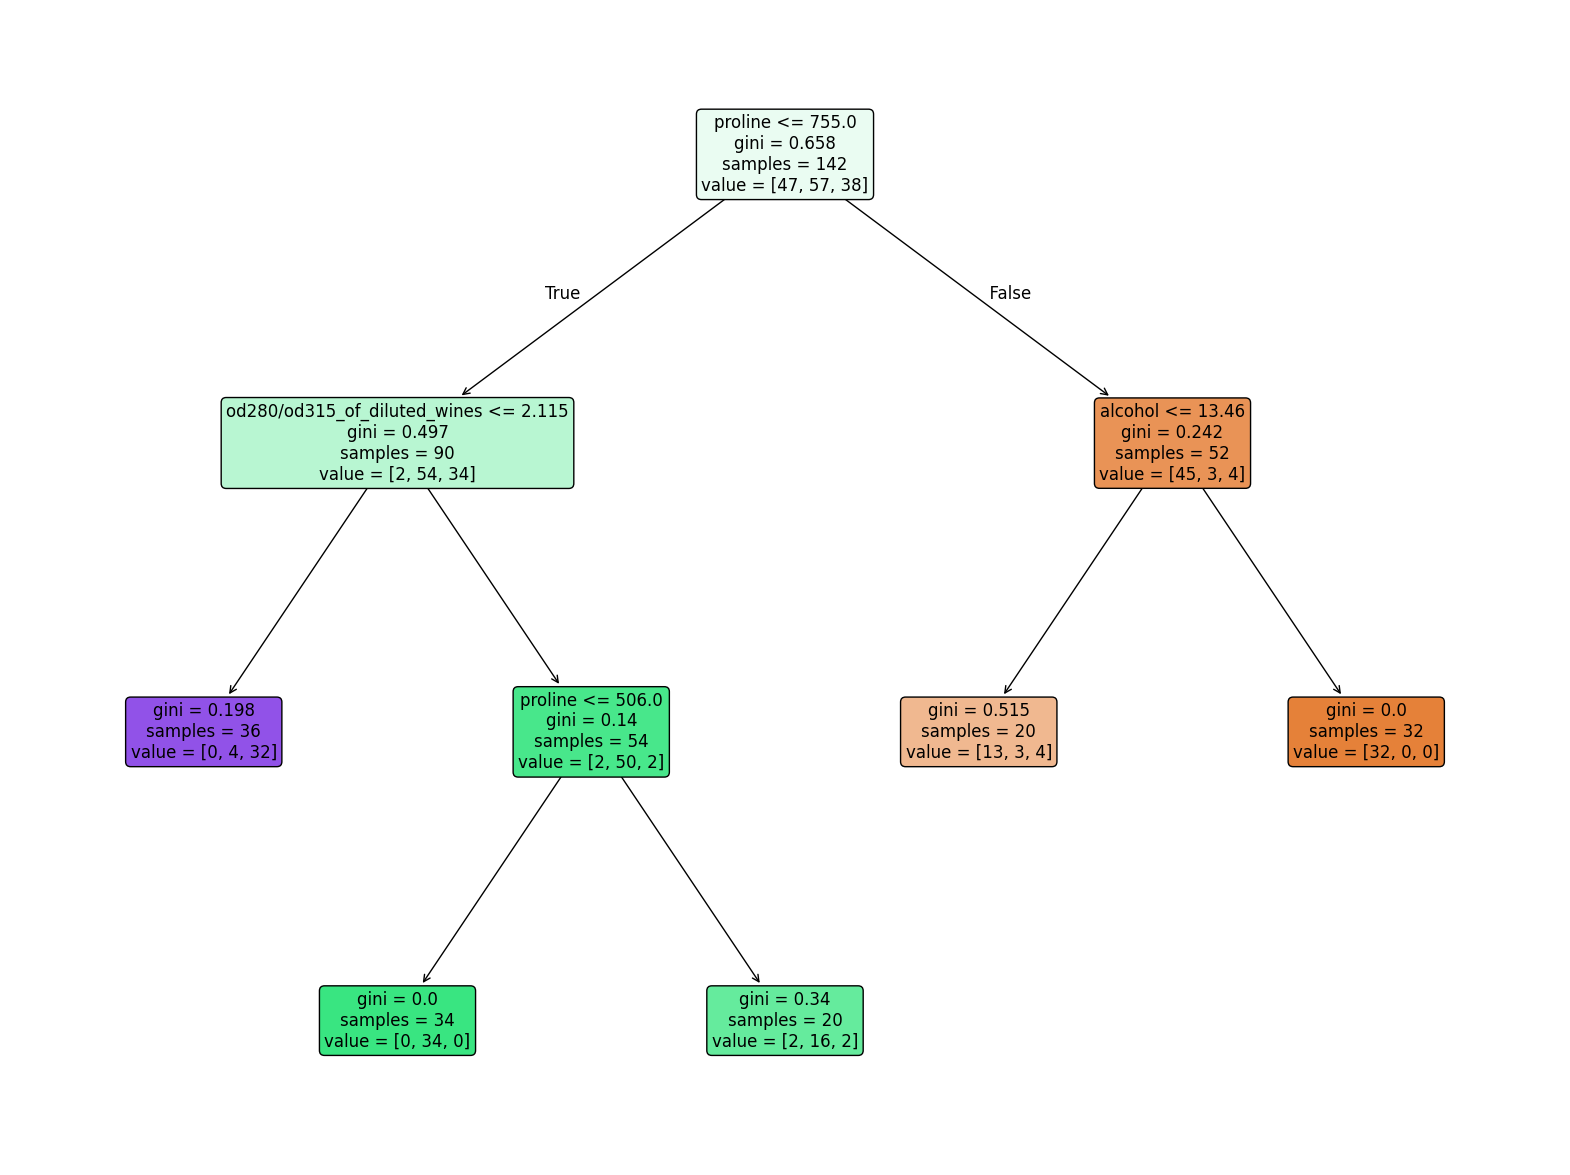

In [100]:
# второй способ отрисовать деревья с помощью plot_tree
plt.figure(figsize=(20, 15))
plot_tree(dt_classifier, feature_names=X.columns, filled=True, rounded=True,  fontsize=12)
plt.show()

In [102]:
pd.DataFrame(
    {"feature": X_train.columns, "importance": dt_classifier.feature_importances_}
).sort_values(by="importance", ascending=False).reset_index(drop=True)

,feature,importance
0,proline,0.532815
1,od280/od315_of_diluted_wines,0.434273
2,alcohol,0.032911
3,malic_acid,0.000000
4,ash,0.000000
5,magnesium,0.000000
6,alcalinity_of_ash,0.000000
7,total_phenols,0.000000
8,flavanoids,0.000000
9,proanthocyanins,0.000000


In [112]:
# Создание и обучение модели дерева решений с поиском по сетке
param_grid = {
    'max_depth': [ 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5, 10, 15],
    'ccp_alpha': [0.01, 0.02, 0.03]
}

dt_classifier = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(dt_classifier, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'ccp_alpha': [0.01, 0.02, 0.03],
                         'max_depth': [3, 4, 5],
                         'min_samples_leaf': [5, 10, 15],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [1]:
3*3*3*3*5

81

In [113]:
best_params = grid_search.best_params_
best_params

{'ccp_alpha': 0.01,
 'max_depth': 3,
 'min_samples_leaf': 5,
 'min_samples_split': 2}

In [114]:
best_dt_classifier = grid_search.best_estimator_
best_dt_classifier

DecisionTreeClassifier(ccp_alpha=0.01, max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [115]:
pd.DataFrame(grid_search.cv_results_).sort_values('rank_test_score')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_ccp_alpha,param_max_depth,param_min_samples_leaf,param_min_samples_split,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.012218,0.005690,0.009074,0.001586,0.01,3,5,2,"{'ccp_alpha': 0.01, 'max_depth': 3, 'min_sampl...",0.793103,0.965517,0.857143,0.821429,0.857143,0.858867,0.058492,1
1,0.009053,0.004036,0.011661,0.003156,0.01,3,5,5,"{'ccp_alpha': 0.01, 'max_depth': 3, 'min_sampl...",0.793103,0.965517,0.857143,0.821429,0.857143,0.858867,0.058492,1
2,0.011093,0.004181,0.008495,0.003579,0.01,3,5,10,"{'ccp_alpha': 0.01, 'max_depth': 3, 'min_sampl...",0.793103,0.965517,0.857143,0.821429,0.857143,0.858867,0.058492,1
9,0.012341,0.002937,0.007365,0.001998,0.01,4,5,2,"{'ccp_alpha': 0.01, 'max_depth': 4, 'min_sampl...",0.793103,0.965517,0.857143,0.821429,0.857143,0.858867,0.058492,1
10,0.011141,0.001525,0.006535,0.003315,0.01,4,5,5,"{'ccp_alpha': 0.01, 'max_depth': 4, 'min_sampl...",0.793103,0.965517,0.857143,0.821429,0.857143,0.858867,0.058492,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.004857,0.001313,0.004040,0.003144,0.03,4,15,10,"{'ccp_alpha': 0.03, 'max_depth': 4, 'min_sampl...",0.724138,0.931034,0.857143,0.821429,0.750000,0.816749,0.074494,55
70,0.013008,0.003523,0.002628,0.000160,0.03,4,15,5,"{'ccp_alpha': 0.03, 'max_depth': 4, 'min_sampl...",0.724138,0.931034,0.857143,0.821429,0.750000,0.816749,0.074494,55
78,0.002891,0.000626,0.001778,0.000380,0.03,5,15,2,"{'ccp_alpha': 0.03, 'max_depth': 5, 'min_sampl...",0.724138,0.931034,0.857143,0.821429,0.750000,0.816749,0.074494,55
79,0.003696,0.000580,0.002376,0.000507,0.03,5,15,5,"{'ccp_alpha': 0.03, 'max_depth': 5, 'min_sampl...",0.724138,0.931034,0.857143,0.821429,0.750000,0.816749,0.074494,55
